# VP-SDE DDPM++ on Oxford Flowers without Augmentation

Train and evaluate a VP-SDE score model with a DDPM++/NCSN++ backbone on plain Oxford Flowers images.


In [ ]:
RUN_TRAINING = True
RUN_EVALUATION_AFTER_TRAINING = True

LOAD_FROM_CHECKPOINT = False
CHECKPOINT_TO_LOAD = "/content/drive/MyDrive/DD2424/Project/working_nets/flower_vp_sde_non_augmented_ddpmpp_1760_epochs.pth"

SAVE_CHECKPOINTS = False

target_class_name = "flowers"
batch_size=128

# Training
epochs=1760
learning_rate = 1e-4
weight_decay=1e-4
ema_decay=0.995

# VP-SDE beta schedule
bar_b_min = 0.1
bar_b_max = 20.0

# Sampling
sample_num_steps = 1000
sample_eps = 1e-3
sample_snr = 0.01
sample_corrector_steps = 0

# Evaluation
fid_num_generated = 1000
fid_gen_batch_size = 64
mem_num_generated = 64
mem_reference_images = 5000

# Paths
path = "/content/drive/MyDrive/DD2424/Project/working_nets"


## Imports and project setup

This cell loads the required libraries, selects GPU if available, and connects the notebook to Drive.  
All checkpoints, plots, and generated images are saved in the project folder.


In [ ]:
import os
import sys
import math
import time
import copy
import subprocess
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from tqdm import tqdm


device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

from google.colab import drive

drive.mount("/content/drive")
os.makedirs(path, exist_ok=True)
project_root = os.path.dirname(path) if os.path.basename(path) == "working_nets" else path
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if path not in sys.path:
    sys.path.insert(0, path)

print("Project path:", path)
print("Files in project path:", os.listdir(path))


Using device: cuda
Mounted at /content/drive
Project path: /content/drive/MyDrive/DD2424/Project/working_nets
Files in project path: ['score_sde_pytorch', 'bird_ncsnpp_ve_ema_checkpoint_epoch_500.pth', 'bird_ncsnpp_ve_ema_checkpoint_epoch_621.pth', 'bird_ncsnpp_ve_ema_checkpoint_epoch_1000.pth', 'bird_ncsnpp_ve_ema_checkpoint_epoch_1500.pth', 'bird_ncsnpp_ve_ema_checkpoint_epoch_1759.pth', 'bird_ncsnpp_ve_ema_checkpoint_epoch_1760.pth']


In [ ]:
from src.plotting import denormalize, imshow, show_batch_from_loader, show_images, plot_loss, save_tensor_images_as_grid
from src.configs import create_ddpmpp_vp_config
from src.sde import update_ema


## Load Oxford Flowers without augmentation

The dataset is resized and normalized, but no random crops, flips, rotations, or affine transformations are applied.  
Training therefore uses samples \(x_0\) directly from the plain image distribution.


In [ ]:
# Plain transform: used for training, visualization, FID real images, and memorization check.
transform_plain = transforms.Compose([transforms.Resize((48, 48)), transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Load full plain training set.
trainset_plain = torchvision.datasets.Flowers102(root='./data', split='train', download=True, transform=transform_plain)

# Reference loader keeps a fixed order for visualization and memorization checks.
trainloader_plain = DataLoader(trainset_plain, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Training loader uses the same plain images, only shuffled between batches.
trainloader = DataLoader(trainset_plain, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

# Test set: plain transform, full dataset.
testset = torchvision.datasets.Flowers102(root='./data', split='test', download=True, transform=transform_plain)

testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("Dataset: Oxford Flowers")
print("Number of training images:", len(trainset_plain))
print("Number of test images:", len(testset))
print("Steps per epoch:", math.ceil(len(trainset_plain) / batch_size))


100%|██████████| 345M/345M [00:01<00:00, 230MB/s]
100%|██████████| 502/502 [00:00<00:00, 3.90MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 110MB/s]


Dataset: Oxford Flowers
Number of training images: 1020
Number of test images: 6149
Steps per epoch: 8


## Visualize plain training images

This checks that the images are loaded correctly after resizing and normalization.  
The displayed grid is only for inspection and does not alter the data.


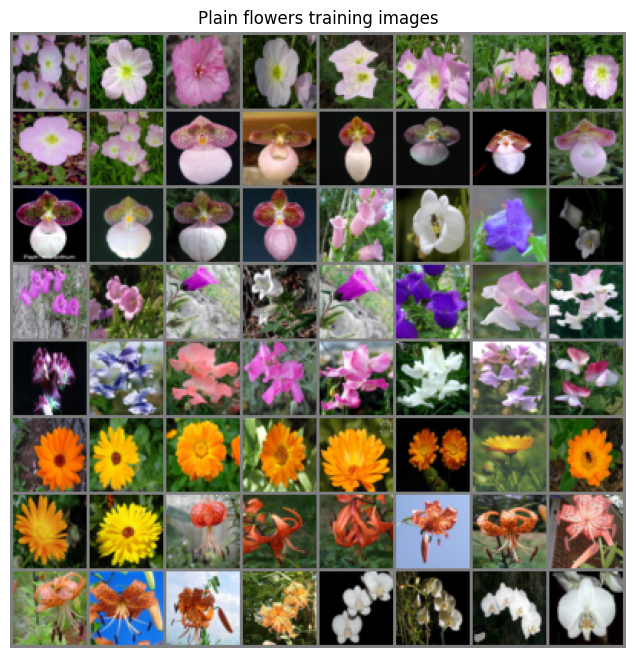

In [ ]:
show_batch_from_loader(trainloader_plain, title="Plain flowers training images")


## Import DDPM++ architecture

This downloads the score-based modeling repository if needed and imports the DDPM++/NCSN++ network.  
The network is used as the score model inside the VP-SDE framework.


In [ ]:
!pip install ninja

from types import SimpleNamespace

score_sde_repository_path = os.path.join(path, "score_sde_pytorch")

if not os.path.exists(score_sde_repository_path):
    !git clone https://github.com/yang-song/score_sde_pytorch.git "{score_sde_repository_path}"

if score_sde_repository_path not in sys.path:
    sys.path.insert(0, score_sde_repository_path)

from models.ncsnpp import NCSNpp

print("Imported NCSNpp architecture.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 10.3 MB/s eta 0:00:00
Imported NCSNpp architecture.


## Configure the score network

This creates the DDPM++ model for \(48\times48\) RGB images.  
The model receives noisy images and continuous time labels, then outputs a score estimate.


In [ ]:
class NCSNppVPScoreWrapper(nn.Module):
    def __init__(self, official_model, number_of_scales=1000):
        super().__init__()
        self.official_model = official_model
        self.number_of_scales = number_of_scales

        def forward(self, images, continuous_timesteps):
            timestep_labels = continuous_timesteps * (self.number_of_scales - 1)
            model_output = self.official_model(images, timestep_labels)

            _, standard_deviation = perturbation_kernel(continuous_timesteps, images)
            score = -model_output / standard_deviation

        return score


ncsnpp_config = create_ddpmpp_vp_config(image_size=48, image_channels=3)

official_ddpmpp_model = NCSNpp(ncsnpp_config).to(device)


## VP-SDE training objective

The forward process uses a linear noise schedule \(\beta(t)\).  
Training minimizes a denoising score-matching loss of the form  
\[
\mathbb{E}\left[\sigma_t^2\lVert s_\theta(x_t,t)-\nabla_{x_t}\log p(x_t|x_0)\rVert^2\right].
\]


In [ ]:
def perturbation_kernel(t, x0):
    integral_beta = bar_b_min * t + 0.5 * (bar_b_max - bar_b_min) * t ** 2
    mean = torch.exp(-0.5 * integral_beta).view(-1, 1, 1, 1) * x0
    std = torch.sqrt(1.0 - torch.exp(-integral_beta)).view(-1, 1, 1, 1)
    return mean, std


def vp_loss(x0, net):
    """Continuous VP-SDE denoising score-matching loss."""
    B = x0.shape[0]
    eps=1e-5
    t = torch.rand(B, device=device) * (1.0 - eps) + eps
    z = torch.randn_like(x0)

    mean, std = perturbation_kernel(t, x0)
    x_t = mean + std * z

    score_target = -z / std
    score_pred = net(x_t, t)
    loss = (std ** 2 * ((score_pred - score_target) ** 2)).mean()
    return loss


def beta_t(t):
    return bar_b_min + t * (bar_b_max - bar_b_min)


## Initialize or resume training

This creates the score model, an exponential moving average copy, and the optimizer.  
When resuming, the checkpoint restores the model state, optimizer state, and loss history.


In [ ]:
if LOAD_FROM_CHECKPOINT:
    print("Loading checkpoint:", CHECKPOINT_TO_LOAD)

    checkpoint = torch.load(CHECKPOINT_TO_LOAD, map_location=device)

    vp_net = NCSNppVPScoreWrapper(official_model=official_ddpmpp_model, number_of_scales=ncsnpp_config.model.num_scales).to(device)

    number_of_parameters = sum(parameter.numel() for parameter in vp_net.parameters())

    ema_net = copy.deepcopy(vp_net).to(device)
    ema_net.eval()

    vp_net.load_state_dict(checkpoint["vp_net"])
    ema_net.load_state_dict(checkpoint["ema_net"])

    learning_rate = checkpoint.get("learning_rate", learning_rate)
    weight_decay=checkpoint.get("weight_decay", weight_decay)
    ema_decay=checkpoint.get("ema_decay", ema_decay)
    loss_hist = checkpoint.get("loss_hist", [])
    start_epoch=checkpoint.get("epochs", 0)

    optimizer = optim.AdamW(vp_net.parameters(), lr=learning_rate, weight_decay=weight_decay)

    optimizer.load_state_dict(checkpoint["optimizer"])

    for state in optimizer.state.values():
        for k, v in state.items():
            if torch.is_tensor(v):
                state[k] = v.to(device)

                vp_net.train()
                ema_net.eval()

            for p in ema_net.parameters():
                p.requires_grad_(False)

                print("Loaded checkpoint.")
                print("Start epoch:", start_epoch)
                print("Loaded loss history length:", len(loss_hist))

else:
    print("Initializing new model.")

    vp_net = NCSNppVPScoreWrapper(official_model=official_ddpmpp_model, number_of_scales=ncsnpp_config.model.num_scales).to(device)

    number_of_parameters = sum(parameter.numel() for parameter in vp_net.parameters())

    ema_net = copy.deepcopy(vp_net).to(device)
    ema_net.eval()

    for p in ema_net.parameters():
        p.requires_grad_(False)

        optimizer = optim.AdamW(vp_net.parameters(), lr=learning_rate, weight_decay=weight_decay)

        loss_hist = []
        start_epoch=0

        print("New model initialized.")

print("Number of parameters:", number_of_parameters)


Initializing new model.
New model initialized.
Number of parameters: 9889091


## Training loop

Each batch is diffused to a random time \(t\), and the network learns to reverse that corruption.  
Checkpoints are saved with non-augmented metadata so they can be compared fairly with augmented models.


In [ ]:
def train_vp_sde(vp_net, ema_net, optimizer, trainloader, start_epoch=0, epochs=1760, ema_decay=0.995, checkpoint_every=500, checkpoint_prefix="flower_vp_sde_non_augmented_ddpmpp"):
    global loss_hist
    end_epoch = start_epoch + epochs

    for epoch in tqdm(range(start_epoch, end_epoch)):
        vp_net.train()
        ema_net.eval()
        epoch_losses = []

        for i, (images, _) in enumerate(trainloader):
            images = images.to(device)
            loss = vp_loss(images, vp_net)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(vp_net.parameters(), max_norm=1.0)
            optimizer.step()
            update_ema(ema_net, vp_net, decay=ema_decay)

            loss_hist.append(loss.item())
            epoch_losses.append(loss.item())

        if epoch % 10 == 0:
            print(f"VP epoch {epoch} | Mean loss {np.mean(epoch_losses):.4f}")

        if SAVE_CHECKPOINTS and checkpoint_every is not None and (epoch + 1) % checkpoint_every == 0:
            checkpoint_path = os.path.join(path, f"{checkpoint_prefix}_{epoch + 1}_epochs.pth")
            checkpoint = {"vp_net": vp_net.state_dict(), "ema_net": ema_net.state_dict(), "optimizer": optimizer.state_dict(), "loss_hist": loss_hist}
            checkpoint["epochs"] = epoch + 1
            checkpoint["batch_size"] = batch_size
            checkpoint["learning_rate"] = learning_rate
            checkpoint["weight_decay"] = weight_decay
            checkpoint["ema_decay"] = ema_decay
            checkpoint["bar_b_min"] = bar_b_min
            checkpoint["bar_b_max"] = bar_b_max
            checkpoint["augmentation"] = False
            checkpoint["target_class_name"] = target_class_name
            torch.save(checkpoint, checkpoint_path)
            print("Saved checkpoint:", checkpoint_path)

    return end_epoch


## Run training

This trains the non-augmented model on the plain Oxford Flowers training set.  
The final checkpoint stores both the raw model and its EMA version.


In [ ]:
if RUN_TRAINING:
    print("Training VP-SDE model on non-augmented Oxford Flowers data...")
    final_epoch = train_vp_sde(vp_net, ema_net, optimizer, trainloader, start_epoch=start_epoch, epochs=epochs, ema_decay=ema_decay, checkpoint_every=500, checkpoint_prefix="flower_vp_sde_non_augmented_ddpmpp")
    final_checkpoint_path = os.path.join(path, f"flower_vp_sde_non_augmented_final_ddpmpp_{final_epoch}_epochs.pth")
    checkpoint = {"vp_net": vp_net.state_dict(), "ema_net": ema_net.state_dict(), "optimizer": optimizer.state_dict(), "loss_hist": loss_hist}
    checkpoint["epochs"] = final_epoch
    checkpoint["batch_size"] = batch_size
    checkpoint["learning_rate"] = learning_rate
    checkpoint["weight_decay"] = weight_decay
    checkpoint["ema_decay"] = ema_decay
    checkpoint["bar_b_min"] = bar_b_min
    checkpoint["bar_b_max"] = bar_b_max
    checkpoint["augmentation"] = False
    checkpoint["target_class_name"] = target_class_name
    torch.save(checkpoint, final_checkpoint_path)
    print("Saved final checkpoint:", final_checkpoint_path)

else:
    final_epoch = start_epoch


Training VP-SDE model on non-augmented Oxford Flowers data...


  0%|          | 1/1760 [00:02<1:11:35,  2.44s/it]

VP epoch 0 | Mean loss 0.9711


  1%|          | 11/1760 [00:12<30:30,  1.05s/it]

VP epoch 10 | Mean loss 0.2883


...

VP epoch 1740 | Mean loss 0.0268


 99%|█████████▉| 1751/1760 [30:16<00:09,  1.03s/it]

VP epoch 1750 | Mean loss 0.0270


100%|██████████| 1760/1760 [30:25<00:00,  1.04s/it]

Saved final checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/flower_vp_sde_non_augmented_final_ddpmpp_1760_epochs.pth


## Plot training loss

This visualizes the score-matching loss over optimization steps.  
A moving average is added to make the long-run training trend easier to see.


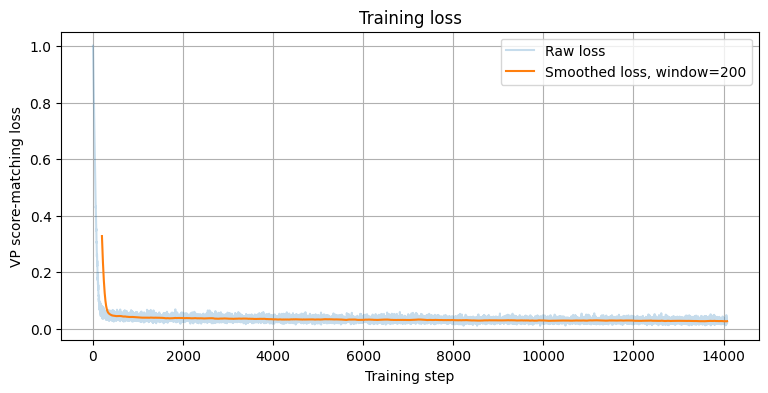

In [ ]:
plot_loss(loss_hist, smooth_window=200)


## Reverse-time sampling

Sampling starts from Gaussian noise and follows the learned reverse VP-SDE.  
The predictor step approximates the reverse dynamics, and the optional corrector refines samples using the score.


In [ ]:
@torch.no_grad()
def langevin_corrector_vp(x, t, net, snr=0.05, n_steps=1, eps=1e-12):
    B = x.shape[0]
    batch_t = torch.ones(B, device=device) * t

    for _ in range(n_steps):
        score = net(x, batch_t)
        noise = torch.randn_like(x)
        score_norm = torch.norm(score.reshape(B, -1), dim=1).mean()
        noise_norm = torch.norm(noise.reshape(B, -1), dim=1).mean()
        step_size = 2.0 * (snr * noise_norm / (score_norm + eps)) ** 2

        x_mean = x + step_size * score
        x = x_mean + torch.sqrt(2.0 * step_size) * noise

    return x, x_mean


@torch.no_grad()
def euler_maruyama_predictor_vp(x, t, t_next, net, add_noise=True):
    B = x.shape[0]
    h = t - t_next
    batch_t = torch.ones(B, device=device) * t

    beta = beta_t(batch_t).view(-1, 1, 1, 1)
    score = net(x, batch_t)
    drift = 0.5 * beta * x + beta * score
    x_mean = x + drift * h

    if add_noise:
        noise = torch.randn_like(x)
        x = x_mean + torch.sqrt(beta * h) * noise
    else:
        x = x_mean

    return x, x_mean


@torch.no_grad()
def sample_pc_vp_sde_continuous(net, num_samples=64, img_shape=(3, 48, 48), num_steps=1000, eps=1e-3, snr=0.05, corrector_steps=0, denoise=True):
    net.eval()
    x = torch.randn(num_samples, *img_shape, device=device)
    timesteps = torch.linspace(1.0, eps, num_steps, device=device)
    x_mean = x

    for i in tqdm(range(num_steps - 1)):
        t = timesteps[i]
        t_next = timesteps[i + 1]

        if corrector_steps > 0:
            x, x_mean = langevin_corrector_vp(x, t, net, snr=snr, n_steps=corrector_steps)

        add_noise = i < num_steps - 2
        x, x_mean = euler_maruyama_predictor_vp(x, t, t_next, net, add_noise=add_noise)

    return (x_mean if denoise else x).clamp(-1, 1)


## Generate sample grids

This creates visual samples from both the EMA model and the raw trained model.  
The images are saved as grids for later comparison.


100%|██████████| 999/999 [00:09<00:00, 107.20it/s]


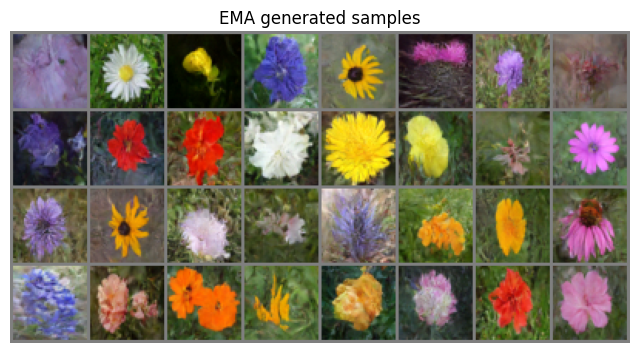

100%|██████████| 999/999 [00:09<00:00, 107.06it/s]


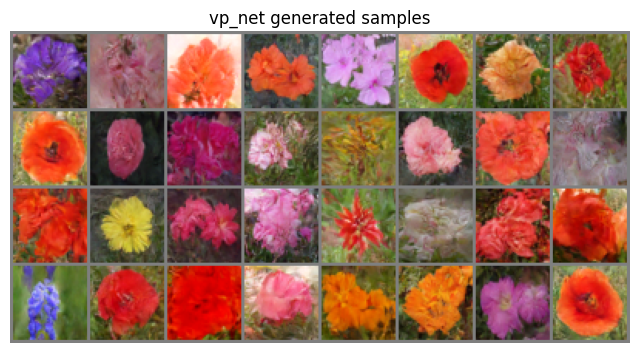

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/ema_generated_samples_grid.png
Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/vp_generated_samples_grid.png


In [ ]:
samples_ema = sample_pc_vp_sde_continuous(ema_net, num_samples=32, img_shape=(3, 48, 48), num_steps=sample_num_steps,
    eps=sample_eps, snr=sample_snr, corrector_steps=sample_corrector_steps, denoise=True)

show_images(samples_ema, title="EMA generated samples", nrow=8)

samples_raw = sample_pc_vp_sde_continuous(vp_net, num_samples=32, img_shape=(3, 48, 48), num_steps=sample_num_steps,
    eps=sample_eps, snr=sample_snr, corrector_steps=sample_corrector_steps, denoise=True)

show_images(samples_raw, title="vp_net generated samples", nrow=8)


save_tensor_images_as_grid(samples_ema, os.path.join(path, 'ema_generated_samples_grid.png'), nrow=8)

save_tensor_images_as_grid(samples_raw, os.path.join(path, 'vp_generated_samples_grid.png'), nrow=8)


## Evaluation utilities

This section generates batches, computes FID against real test images, and prepares nearest-neighbor checks.  
FID measures distributional similarity, while pixel-space nearest neighbors give a rough memorization diagnostic.


In [ ]:
@torch.no_grad()
def generate_samples_in_batches(model, total_samples=1000, sample_batch_size=64, img_shape=(3, 48, 48), num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=0, denoise=True):
    model.eval()
    all_samples = []
    generated = 0

    while generated < total_samples:
        current_batch = min(sample_batch_size, total_samples - generated)
        samples = sample_pc_vp_sde_continuous(model, num_samples=current_batch, img_shape=img_shape, num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise)
        all_samples.append(samples.detach().cpu())
        generated += current_batch
        print(f"Generated {generated}/{total_samples} samples")

    return torch.cat(all_samples, dim=0)


def to_uint8_images(x):
    x = denormalize(x)
    x = (x * 255.0).round().clamp(0, 255).to(torch.uint8)
    return x


def install_fid_dependencies_if_needed():
    try:
        from torchmetrics.image.fid import FrechetInceptionDistance
        return FrechetInceptionDistance
    except Exception:
        print("Installing torchmetrics and torch-fidelity...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchmetrics", "torch-fidelity"])
        from torchmetrics.image.fid import FrechetInceptionDistance
        return FrechetInceptionDistance


@torch.no_grad()
def compute_fid_for_model(model, real_loader, num_generated=1000, gen_batch_size=64, real_max_images=1000, num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=0, denoise=True, feature=2048):
    FrechetInceptionDistance = install_fid_dependencies_if_needed()
    fid = FrechetInceptionDistance(feature=feature, normalize=False).to(device)
    model.eval()

    real_count = 0
    for real_images, _ in real_loader:
        real_images = real_images.to(device)
        fid.update(to_uint8_images(real_images), real=True)
        real_count += real_images.shape[0]
        if real_count >= real_max_images:
            break

    print("Real images added to FID:", real_count)

    gen_count = 0
    while gen_count < num_generated:
        current_batch = min(gen_batch_size, num_generated - gen_count)
        samples = sample_pc_vp_sde_continuous(
            model, num_samples=current_batch, img_shape=(3, 48, 48),
            num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise
        )
        fid.update(to_uint8_images(samples), real=False)
        gen_count += current_batch
        print(f"Generated images added to FID: {gen_count}/{num_generated}")

    fid_value = fid.compute().item()
    print("FID:", fid_value)
    return fid_value


def fid_sampling_steps_experiment(model, real_loader, steps_list=(100, 250, 500, 1000), num_generated=1000, gen_batch_size=64, corrector_steps=0):
    results = {}

    for steps in steps_list:
        print("\n====================================")
        print("Computing FID with num_steps =", steps)
        print("====================================")
        start_time = time.time()
        fid_value = compute_fid_for_model(
            model, real_loader, num_generated=num_generated, gen_batch_size=gen_batch_size,
            real_max_images=1000, num_steps=steps, eps=1e-3, snr=0.01,
            corrector_steps=corrector_steps, denoise=True
        )
        elapsed = time.time() - start_time
        results[steps] = {"fid": fid_value, "time_seconds": elapsed}
        print(f"num_steps={steps} | FID={fid_value:.4f} | time={elapsed:.2f}s")

    return results


## Memorization check

Generated samples are compared against training images using nearest-neighbor pixel MSE.  
Very small distances can indicate copying, but this is only a simple diagnostic.


In [ ]:
@torch.no_grad()
def collect_images_from_loader(loader, max_images=5000):
    all_images = []
    count = 0

    for images, _ in loader:
        images = images.to(device)
        all_images.append(images)
        count += images.shape[0]
        if count >= max_images:
            break

    all_images = torch.cat(all_images, dim=0)
    return all_images[:max_images]


@torch.no_grad()
def nearest_neighbor_indices_pixel_mse(generated_images, reference_images, ref_batch_size=512):
    generated_images = generated_images.to(device)
    reference_images = reference_images.to(device)
    N = generated_images.shape[0]
    M = reference_images.shape[0]
    gen_flat = generated_images.reshape(N, -1)
    best_distances = torch.full((N,), float("inf"), device=device)
    best_indices = torch.zeros((N,), dtype=torch.long, device=device)

    for start in range(0, M, ref_batch_size):
        end = min(start + ref_batch_size, M)
        ref_batch = reference_images[start:end]
        ref_flat = ref_batch.reshape(ref_batch.shape[0], -1)
        dists = torch.cdist(gen_flat, ref_flat, p=2) ** 2 / gen_flat.shape[1]
        min_dists, min_idx = dists.min(dim=1)
        better = min_dists < best_distances
        best_distances[better] = min_dists[better]
        best_indices[better] = start + min_idx[better]

    return best_indices.detach().cpu(), best_distances.detach().cpu()


def show_generated_vs_nearest(generated_images, reference_images, nearest_indices, nearest_distances=None, num_show=8):
    generated_images = generated_images.detach().cpu()
    reference_images = reference_images.detach().cpu()
    num_show = min(num_show, generated_images.shape[0])

    pairs = []
    for i in range(num_show):
        pairs.append(generated_images[i])
        pairs.append(reference_images[nearest_indices[i]])

    grid = make_grid(torch.stack(pairs, dim=0), nrow=2)
    img = denormalize(grid).numpy()
    plt.figure(figsize=(6, 3 * num_show))
    plt.imshow(np.transpose(img, (1, 2, 0)))
    plt.axis("off")

    if nearest_distances is not None:
        mean_dist = nearest_distances[:num_show].mean().item()
        plt.title(f"Generated vs nearest training image | mean MSE={mean_dist:.6f}")
    else:
        plt.title("Generated vs nearest training image")

    plt.show()


@torch.no_grad()
def memorization_check(model, trainloader_reference, num_generated=64, generation_batch_size=64, max_reference_images=5000, num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=0, denoise=True, show_num=8):
    print("Collecting reference training images...")
    reference_images = collect_images_from_loader(trainloader_reference, max_images=max_reference_images)
    print("Reference images:", reference_images.shape)

    print("Generating images for memorization check...")
    generated_images = generate_samples_in_batches(model, total_samples=num_generated, sample_batch_size=generation_batch_size,
        img_shape=(3, 48, 48), num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise).to(device)
    print("Generated images:", generated_images.shape)

    print("Finding nearest training neighbors...")
    nearest_indices, nearest_distances = nearest_neighbor_indices_pixel_mse(generated_images, reference_images, ref_batch_size=512)
    print("Mean nearest-neighbor MSE:", nearest_distances.mean().item())
    print("Median nearest-neighbor MSE:", nearest_distances.median().item())
    print("Minimum nearest-neighbor MSE:", nearest_distances.min().item())
    print("Maximum nearest-neighbor MSE:", nearest_distances.max().item())

    show_generated_vs_nearest(generated_images.cpu(), reference_images.cpu(), nearest_indices, nearest_distances, num_show=show_num)
    return {
        "generated_images": generated_images.detach().cpu(), "reference_images": reference_images.detach().cpu(),
        "nearest_indices": nearest_indices, "nearest_distances": nearest_distances
    }


def plot_nearest_neighbor_distance_histogram(mem_results, bins=30):
    distances = mem_results["nearest_distances"].numpy()
    plt.figure(figsize=(7, 4))
    plt.hist(distances, bins=bins)
    plt.xlabel("Nearest-neighbor pixel MSE")
    plt.ylabel("Number of generated samples")
    plt.title("Memorization check: nearest-neighbor distance distribution")
    plt.grid(True)
    plt.show()


def save_memorization_report(mem_results, filename):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    distances = mem_results["nearest_distances"].numpy()

    with open(filename, "w") as f:
        f.write("Memorization nearest-neighbor report\n")
        f.write("====================================\n")
        f.write(f"Number of generated samples: {len(distances)}\n")
        f.write(f"Mean nearest-neighbor MSE: {distances.mean():.8f}\n")
        f.write(f"Median nearest-neighbor MSE: {np.median(distances):.8f}\n")
        f.write(f"Minimum nearest-neighbor MSE: {distances.min():.8f}\n")
        f.write(f"Maximum nearest-neighbor MSE: {distances.max():.8f}\n")

    print("Saved memorization report:", filename)


## Full evaluation routine

This compares raw and EMA samples, computes FID, and runs the memorization check.  
The same sample counts and sampling steps can be reused for fair comparisons.


In [ ]:
def compare_raw_vs_ema(vp_net, ema_net, num_samples=64, num_steps=1000, corrector_steps=0):
    torch.manual_seed(0)
    samples_raw = generate_samples_in_batches(
        model=vp_net, total_samples=num_samples, sample_batch_size=64,
        img_shape=(3, 48, 48), num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )

    torch.manual_seed(0)
    samples_ema = generate_samples_in_batches(
        model=ema_net, total_samples=num_samples, sample_batch_size=64,
        img_shape=(3, 48, 48), num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )

    show_images(samples_raw[:64], title="Raw vp_net samples", nrow=8)
    show_images(samples_ema[:64], title="EMA ema_net samples", nrow=8)
    save_tensor_images_as_grid(samples_raw[:64], os.path.join(path, 'comparison_raw_vp_net_grid.png'), nrow=8)
    save_tensor_images_as_grid(samples_ema[:64], os.path.join(path, 'comparison_ema_net_grid.png'), nrow=8)
    return samples_raw, samples_ema


def run_full_evaluation(model, model_name="ema_net", fid_num_generated=1000, mem_num_generated=64, num_steps=1000, corrector_steps=0):
    print("\n====================================")
    print("Running full evaluation for:", model_name)
    print("====================================")

    samples = generate_samples_in_batches(
        model=model, total_samples=64, sample_batch_size=64,
        img_shape=(3, 48, 48), num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )
    show_images(samples[:64], title=f"{model_name}: generated samples", nrow=8)
    save_tensor_images_as_grid(samples[:64], os.path.join(path, f'{model_name}_generated_grid.png'), nrow=8)

    fid_value = compute_fid_for_model(
        model, testloader, num_generated=fid_num_generated, gen_batch_size=fid_gen_batch_size,
        real_max_images=1000, num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )

    mem_results = memorization_check(model, trainloader_plain, num_generated=mem_num_generated, generation_batch_size=64,
        max_reference_images=mem_reference_images, num_steps=num_steps, eps=1e-3, snr=0.01,
        corrector_steps=corrector_steps, denoise=True, show_num=8)
    plot_nearest_neighbor_distance_histogram(mem_results)

    results = {"model_name": model_name, "fid": fid_value, "num_steps": num_steps, "corrector_steps": corrector_steps}
    results["mem_mean_nn_mse"] = mem_results["nearest_distances"].mean().item()
    results["mem_median_nn_mse"] = mem_results["nearest_distances"].median().item()
    results["mem_min_nn_mse"] = mem_results["nearest_distances"].min().item()
    results["mem_max_nn_mse"] = mem_results["nearest_distances"].max().item()

    results_path = os.path.join(path, f"{model_name}_evaluation_results.txt")
    with open(results_path, "w") as f:
        for k, v in results.items():
            f.write(f"{k}: {v}\n")

    print("Saved evaluation results:", results_path)
    print(results)
    return results


## Evaluate after training

This runs the main evaluation immediately after training, if enabled.  
Both the raw network and EMA network are evaluated once.


100%|██████████| 999/999 [00:08<00:00, 115.50it/s]


Generated 24/24 samples


100%|██████████| 999/999 [00:08<00:00, 116.05it/s]


Generated 24/24 samples


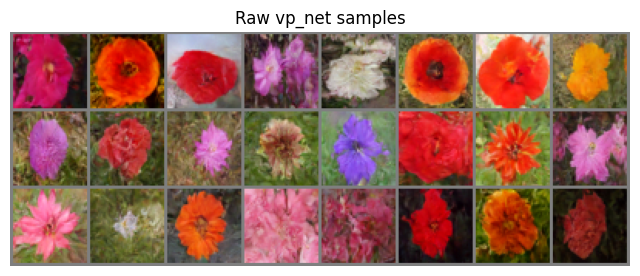

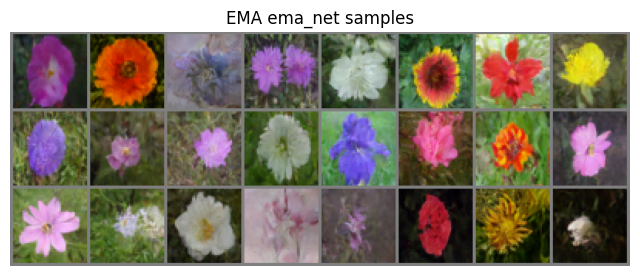

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/comparison_raw_vp_net_grid.png
Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/comparison_ema_net_grid.png

Running full evaluation for: raw_vp_net_flower_1760_epochs


100%|██████████| 999/999 [00:14<00:00, 68.47it/s]


Generated 64/64 samples


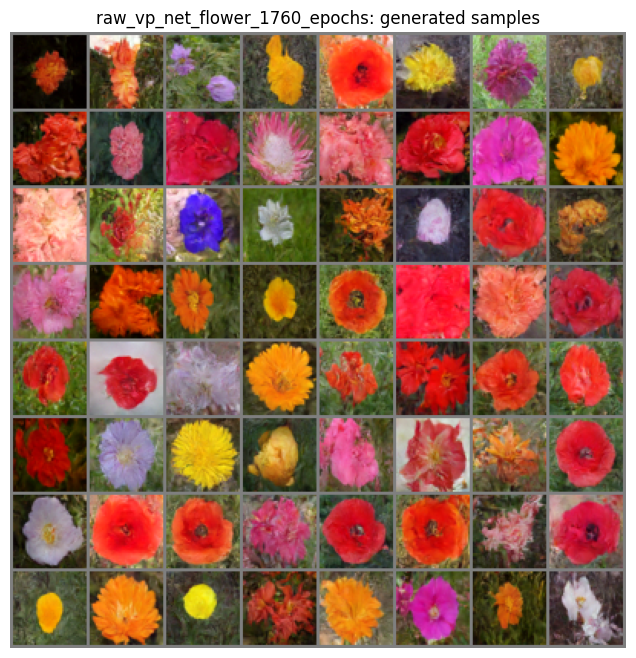

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/raw_vp_net_flower_1760_epochs_generated_grid.png
Installing torchmetrics and torch-fidelity...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 141MB/s]


Real images added to FID: 1024


100%|██████████| 999/999 [00:14<00:00, 68.96it/s]


Generated images added to FID: 64/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [00:11<00:00, 89.02it/s]


Generated images added to FID: 1000/1000
FID: 97.0901107788086
Reference images: torch.Size([1020, 3, 48, 48])
Generating images for memorization check...


100%|██████████| 999/999 [00:14<00:00, 68.70it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 48, 48])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.11882597208023071
Median nearest-neighbor MSE: 0.11871649324893951
Minimum nearest-neighbor MSE: 0.053314775228500366
Maximum nearest-neighbor MSE: 0.24723488092422485


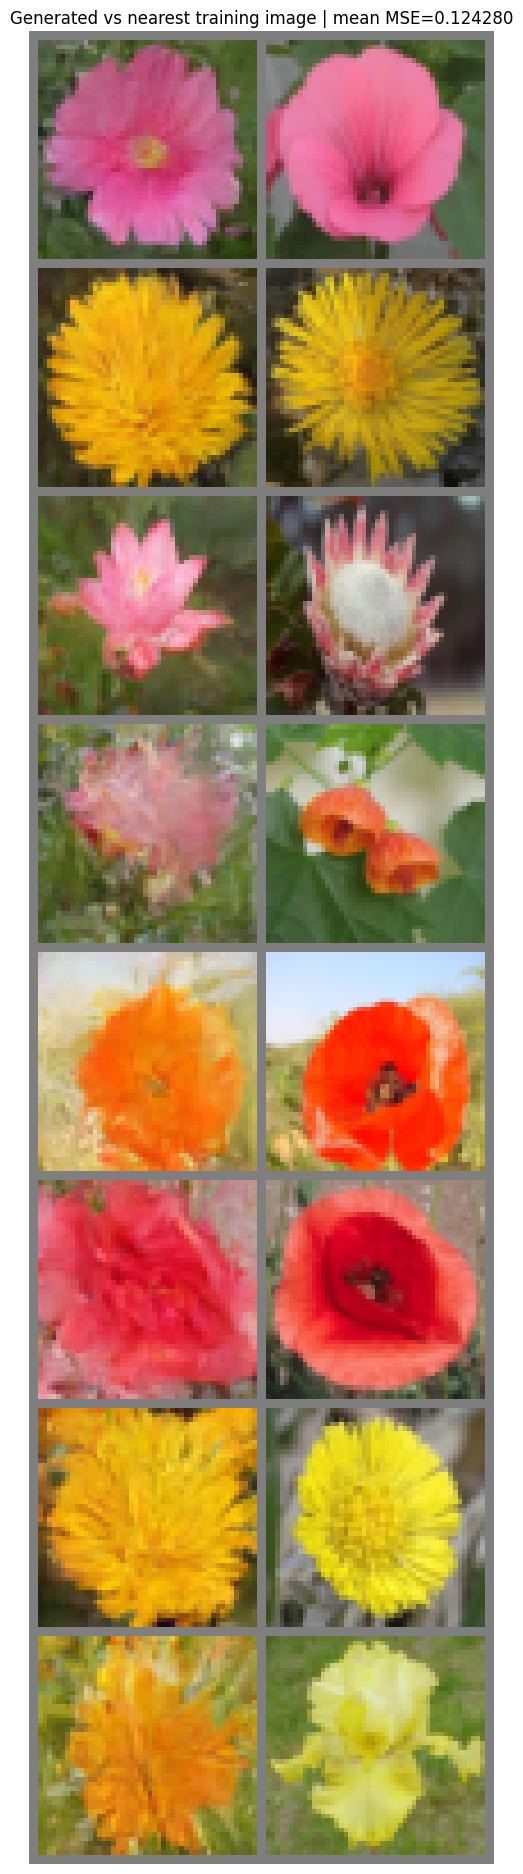

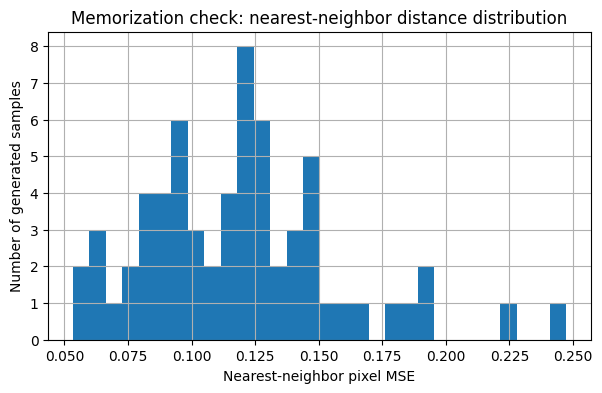

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/working_nets/raw_vp_net_flower_1760_epochs_evaluation_results.txt
{'model_name': 'raw_vp_net_flower_1760_epochs', 'fid': 97.0901107788086, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.11882597208023071, 'mem_median_nn_mse': 0.11871649324893951, 'mem_min_nn_mse': 0.053314775228500366, 'mem_max_nn_mse': 0.24723488092422485}
Final raw VP-net evaluation results:
{'model_name': 'raw_vp_net_flower_1760_epochs', 'fid': 97.0901107788086, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.11882597208023071, 'mem_median_nn_mse': 0.11871649324893951, 'mem_min_nn_mse': 0.053314775228500366, 'mem_max_nn_mse': 0.24723488092422485}

Running full evaluation for: ema_vp_net_flower_1760_epochs


100%|██████████| 999/999 [00:14<00:00, 68.79it/s]


Generated 64/64 samples


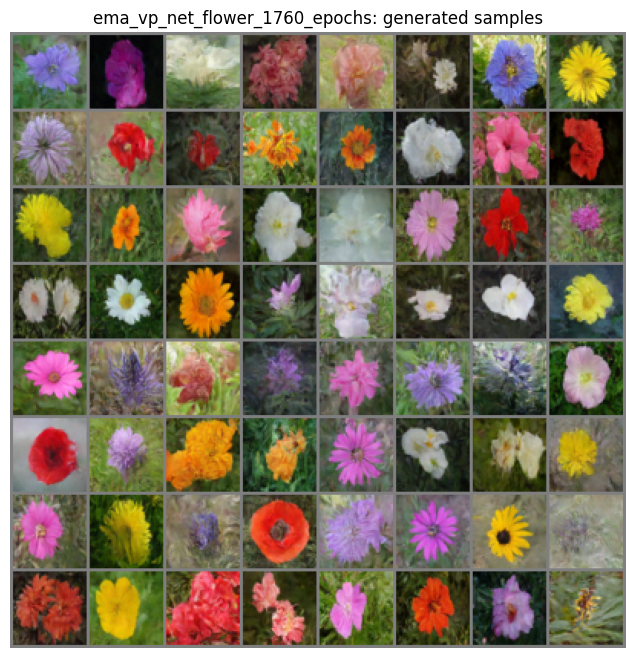

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/ema_vp_net_flower_1760_epochs_generated_grid.png
Real images added to FID: 1024


100%|██████████| 999/999 [00:14<00:00, 68.69it/s]


Generated images added to FID: 64/1000


100%|██████████| 999/999 [00:14<00:00, 68.60it/s]


Generated images added to FID: 128/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [00:11<00:00, 89.09it/s]


Generated images added to FID: 1000/1000
FID: 70.34542083740234
Reference images: torch.Size([1020, 3, 48, 48])
Generating images for memorization check...


100%|██████████| 999/999 [00:14<00:00, 68.65it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 48, 48])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.10789299756288528
Median nearest-neighbor MSE: 0.10292802006006241
Minimum nearest-neighbor MSE: 0.03681144118309021
Maximum nearest-neighbor MSE: 0.2502197325229645


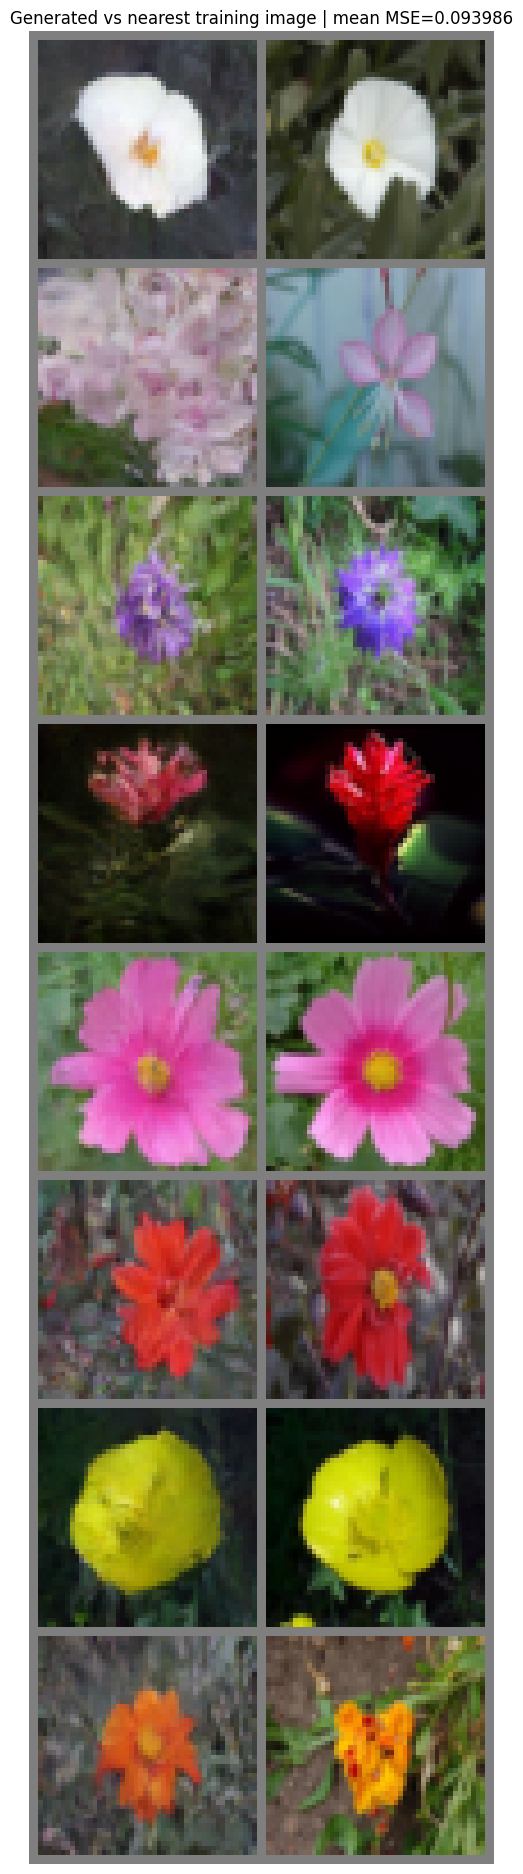

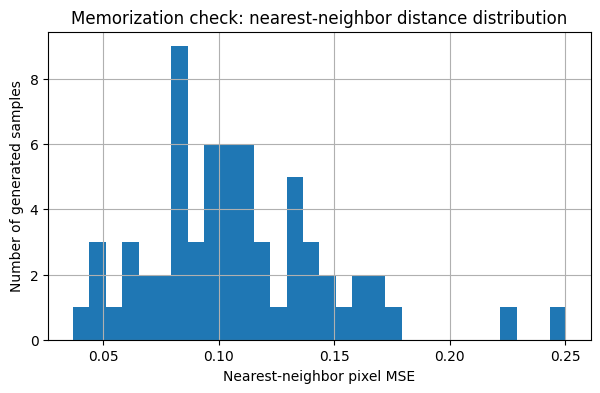

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/working_nets/ema_vp_net_flower_1760_epochs_evaluation_results.txt
{'model_name': 'ema_vp_net_flower_1760_epochs', 'fid': 70.34542083740234, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.10789299756288528, 'mem_median_nn_mse': 0.10292802006006241, 'mem_min_nn_mse': 0.03681144118309021, 'mem_max_nn_mse': 0.2502197325229645}
Final EMA-net evaluation results:
{'model_name': 'ema_vp_net_flower_1760_epochs', 'fid': 70.34542083740234, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.10789299756288528, 'mem_median_nn_mse': 0.10292802006006241, 'mem_min_nn_mse': 0.03681144118309021, 'mem_max_nn_mse': 0.2502197325229645}


In [ ]:
if RUN_EVALUATION_AFTER_TRAINING:
    samples_raw_compare, samples_ema_compare = compare_raw_vs_ema(vp_net=vp_net, ema_net=ema_net, num_samples=24, num_steps=sample_num_steps, corrector_steps=sample_corrector_steps)

    raw_results_after_training = run_full_evaluation(model=vp_net,
        model_name=f"raw_vp_net_flower_{final_epoch}_epochs", fid_num_generated=fid_num_generated,
        mem_num_generated=mem_num_generated, num_steps=sample_num_steps, corrector_steps=sample_corrector_steps)

    print("Final raw VP-net evaluation results:")
    print(raw_results_after_training)

    ema_results_after_training = run_full_evaluation(model=ema_net,
        model_name=f"ema_vp_net_flower_{final_epoch}_epochs", fid_num_generated=fid_num_generated,
        mem_num_generated=mem_num_generated, num_steps=sample_num_steps, corrector_steps=sample_corrector_steps)

    print("Final EMA-net evaluation results:")
    print(ema_results_after_training)


## Evaluate a saved checkpoint

This cell loads a finished non-augmented checkpoint and evaluates it separately.  
Use this when training has already been completed and only final metrics are needed.


Evaluation checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/flower_vp_sde_non_augmented_final_ddpmpp_1760_epochs.pth
FID generated samples: 1000
Memorization generated samples: 64
Sampling steps: 1000
Loaded checkpoint successfully.
Loaded epoch: 1760
Target class: flowers
Augmentation: False
bar_b_min: 0.1
bar_b_max: 20.0

Running full evaluation for: raw_vp_net_flower_1760_epochs


100%|██████████| 999/999 [00:14<00:00, 68.91it/s]


Generated 64/64 samples


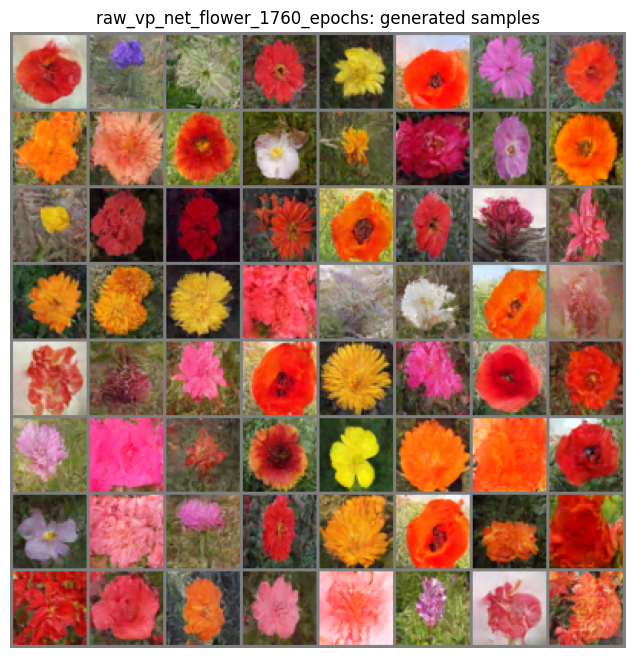

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/raw_vp_net_flower_1760_epochs_generated_grid.png
Real images added to FID: 1024


100%|██████████| 999/999 [00:14<00:00, 68.95it/s]


Generated images added to FID: 64/1000


100%|██████████| 999/999 [00:14<00:00, 68.93it/s]


Generated images added to FID: 128/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [00:11<00:00, 89.22it/s]


Generated images added to FID: 1000/1000
FID: 93.75176239013672
Reference images: torch.Size([1020, 3, 48, 48])
Generating images for memorization check...


100%|██████████| 999/999 [00:14<00:00, 68.68it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 48, 48])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.10391309857368469
Median nearest-neighbor MSE: 0.10561981052160263
Minimum nearest-neighbor MSE: 0.021135540679097176
Maximum nearest-neighbor MSE: 0.22058150172233582


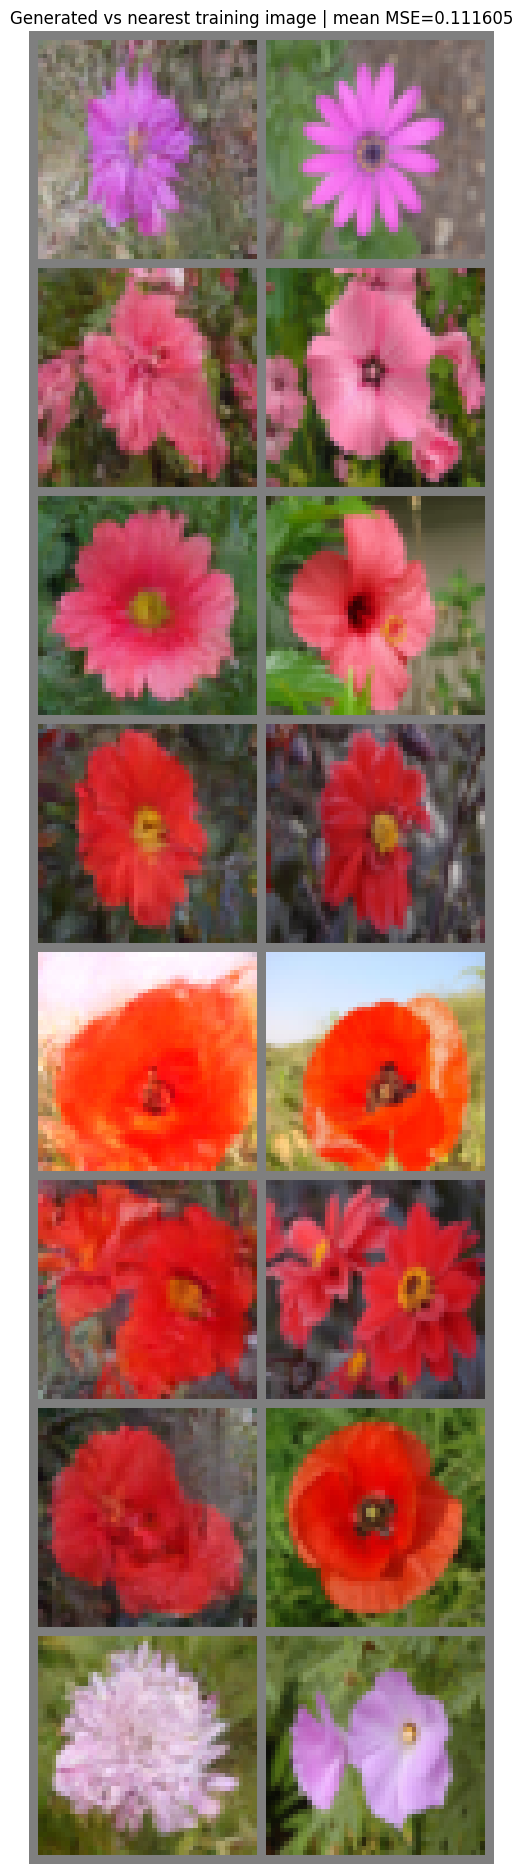

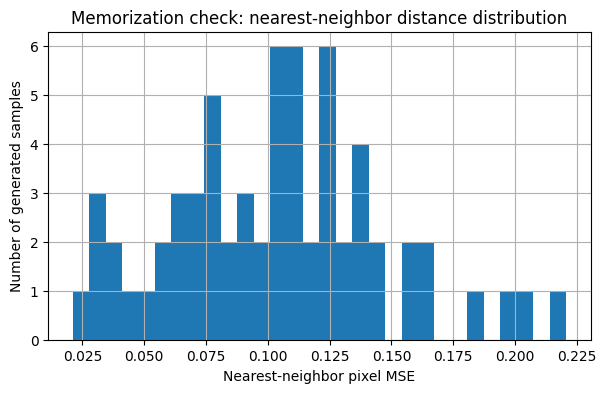

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/working_nets/raw_vp_net_flower_1760_epochs_evaluation_results.txt
{'model_name': 'raw_vp_net_flower_1760_epochs', 'fid': 93.75176239013672, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.10391309857368469, 'mem_median_nn_mse': 0.10561981052160263, 'mem_min_nn_mse': 0.021135540679097176, 'mem_max_nn_mse': 0.22058150172233582}
Raw VP-net evaluation results:
{'model_name': 'raw_vp_net_flower_1760_epochs', 'fid': 93.75176239013672, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.10391309857368469, 'mem_median_nn_mse': 0.10561981052160263, 'mem_min_nn_mse': 0.021135540679097176, 'mem_max_nn_mse': 0.22058150172233582}

Running full evaluation for: ema_vp_net_flower_1760_epochs


100%|██████████| 999/999 [00:14<00:00, 68.91it/s]


Generated 64/64 samples


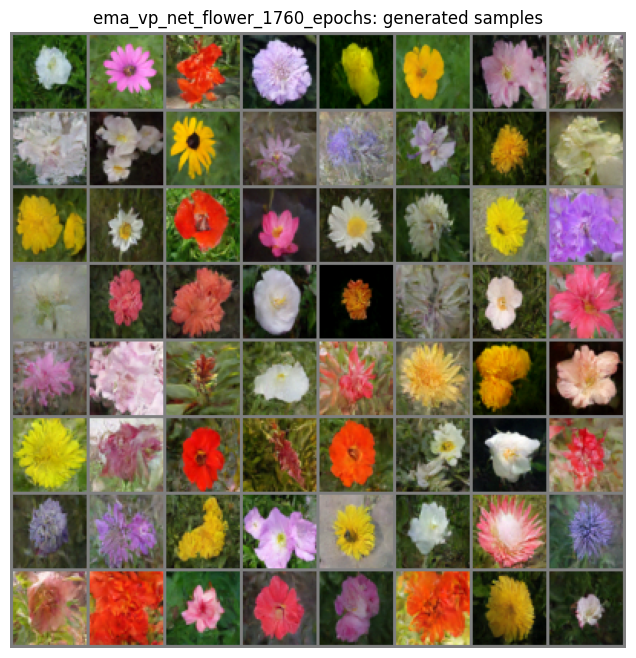

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/ema_vp_net_flower_1760_epochs_generated_grid.png
Real images added to FID: 1024


100%|██████████| 999/999 [00:14<00:00, 69.01it/s]


Generated images added to FID: 64/1000


100%|██████████| 999/999 [00:14<00:00, 68.84it/s]


Generated images added to FID: 128/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [00:11<00:00, 89.52it/s]


Generated images added to FID: 1000/1000
FID: 70.138671875
Reference images: torch.Size([1020, 3, 48, 48])
Generating images for memorization check...


100%|██████████| 999/999 [00:14<00:00, 68.91it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 48, 48])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.09257042407989502
Median nearest-neighbor MSE: 0.09047318249940872
Minimum nearest-neighbor MSE: 0.03891824558377266
Maximum nearest-neighbor MSE: 0.17583361268043518


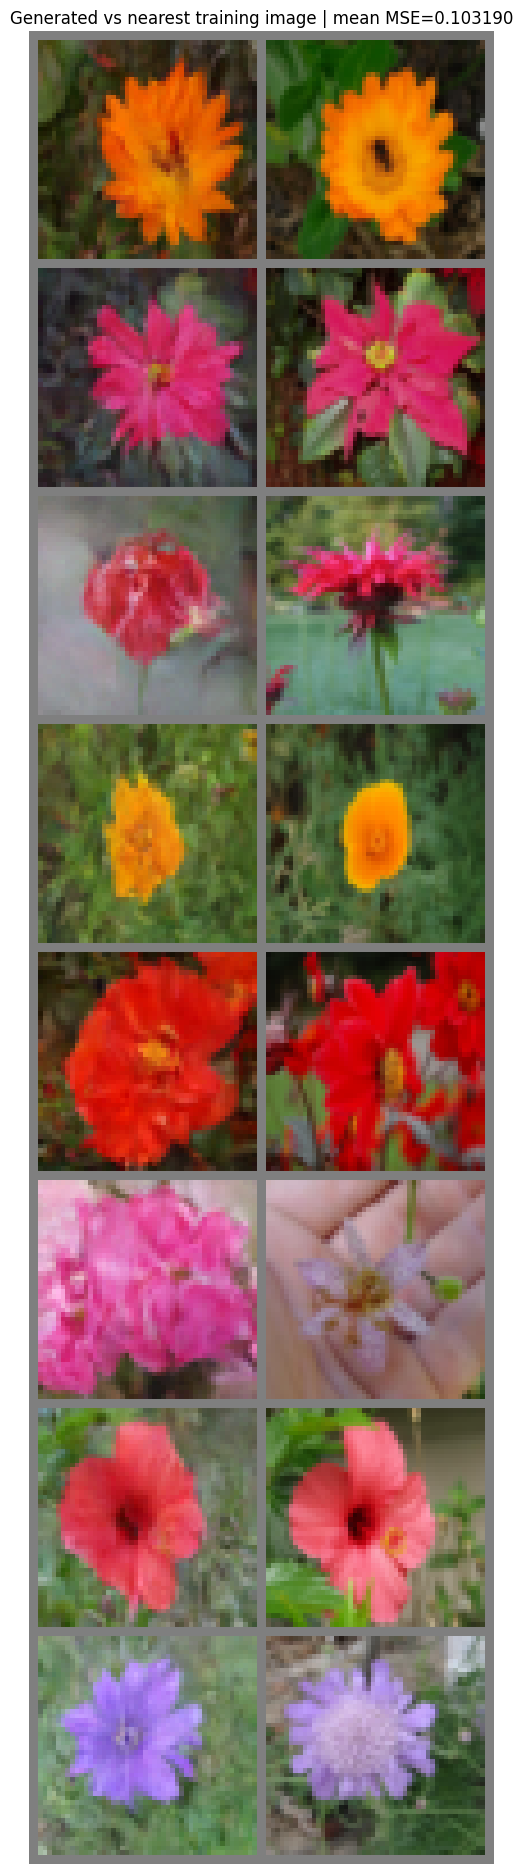

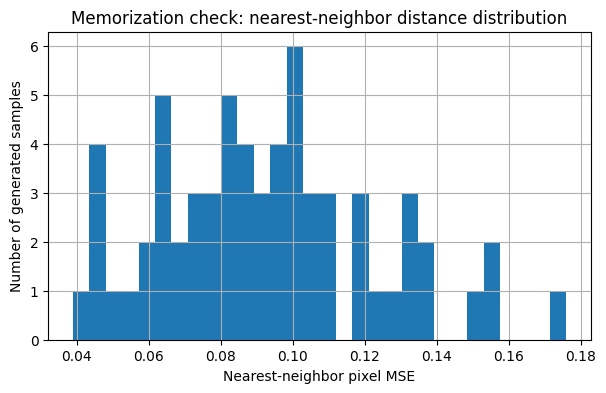

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/working_nets/ema_vp_net_flower_1760_epochs_evaluation_results.txt
{'model_name': 'ema_vp_net_flower_1760_epochs', 'fid': 70.138671875, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.09257042407989502, 'mem_median_nn_mse': 0.09047318249940872, 'mem_min_nn_mse': 0.03891824558377266, 'mem_max_nn_mse': 0.17583361268043518}
EMA VP-net evaluation results:
{'model_name': 'ema_vp_net_flower_1760_epochs', 'fid': 70.138671875, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.09257042407989502, 'mem_median_nn_mse': 0.09047318249940872, 'mem_min_nn_mse': 0.03891824558377266, 'mem_max_nn_mse': 0.17583361268043518}


In [ ]:
eval_checkpoint_path = "/content/drive/MyDrive/DD2424/Project/working_nets/flower_vp_sde_non_augmented_final_ddpmpp_1760_epochs.pth"

eval_epoch = 1760

# The same settings as before.
eval_num_steps = 1000
eval_corrector_steps = 0

# Keep these fixed across augmented and non-augmented models for fair comparison.
eval_fid_num_generated = 1000
eval_mem_num_generated = 64

assert os.path.exists(eval_checkpoint_path), f"Checkpoint not found: {eval_checkpoint_path}"

print("Evaluation checkpoint:", eval_checkpoint_path)
print("FID generated samples:", eval_fid_num_generated)
print("Memorization generated samples:", eval_mem_num_generated)
print("Sampling steps:", eval_num_steps)

checkpoint = torch.load(eval_checkpoint_path, map_location=device)

vp_net_1760 = NCSNppVPScoreWrapper(official_model=official_ddpmpp_model, number_of_scales=ncsnpp_config.model.num_scales).to(device)

ema_net_1760 = copy.deepcopy(vp_net_1760).to(device)
ema_net_1760.eval()

vp_net_1760.load_state_dict(checkpoint["vp_net"])
ema_net_1760.load_state_dict(checkpoint["ema_net"])

vp_net_1760.eval()
ema_net_1760.eval()

for p in vp_net_1760.parameters():
    p.requires_grad_(False)

for p in ema_net_1760.parameters():
    p.requires_grad_(False)

# Restore VP-SDE beta schedule from checkpoint if it exists.
bar_b_min = checkpoint.get("bar_b_min", bar_b_min)
bar_b_max = checkpoint.get("bar_b_max", bar_b_max)

loaded_epoch = checkpoint.get("epochs", eval_epoch)
loaded_target_class = checkpoint.get("target_class_name", target_class_name)
loaded_augmentation = checkpoint.get("augmentation", "unknown")

print("Loaded checkpoint successfully.")
print("Loaded epoch:", loaded_epoch)
print("Target class:", loaded_target_class)
print("Augmentation:", loaded_augmentation)
print("bar_b_min:", bar_b_min)
print("bar_b_max:", bar_b_max)

raw_vp_1760_results = run_full_evaluation(model=vp_net_1760, model_name=f"raw_vp_net_flower_{eval_epoch}_epochs",
    fid_num_generated=eval_fid_num_generated, mem_num_generated=eval_mem_num_generated, num_steps=eval_num_steps,
    corrector_steps=eval_corrector_steps)

print("Raw VP-net evaluation results:")
print(raw_vp_1760_results)

ema_vp_1760_results = run_full_evaluation(model=ema_net_1760, model_name=f"ema_vp_net_flower_{eval_epoch}_epochs",
    fid_num_generated=eval_fid_num_generated, mem_num_generated=eval_mem_num_generated, num_steps=eval_num_steps,
    corrector_steps=eval_corrector_steps)

print("EMA VP-net evaluation results:")
print(ema_vp_1760_results)
